# Inundation Centroid Migration (Figure 5)

Computes the AdDSWE-class-weighted monthly inundation centroid, rotates annual positions
into streamwise/lateral (cross-fan) components, runs trend and change-point tests, and
builds **Figure 5**.

- **Produces:** `centroid_weighted_all.csv` (Dryad `inundation/analysis/centroid/`) and Figure 5.
- **Inputs:** AdDSWE monthly products (EE assets) for centroid extraction; the centroid CSV
  for the annual analysis and figure.

> The centroid-extraction section requires Earth Engine; downstream sections run on the CSV.


# Centroid Migration Analysis Pipeline

End-to-end pipeline for the AdDSWE delta-wide centroid (center-of-mass)
migration analysis. Produces:

1. **Monthly centroids** of delta-wide inundation, pulled from GEE AdDSWE
   assets (lon/lat plus area and pixel counts).
2. **Annual mean centroids** with a ≥8-month-per-year inclusion threshold,
   rotated into streamwise (along-channel) and lateral (cross-channel)
   coordinates using a downstream bearing of 137°.
3. **Trend and change-point tests** on the streamwise and lateral series:
   Mann–Kendall + Sen's slope on the TFPW-blended series (Yue et al. 2002),
   sequential Mann–Kendall (Sneyers 1990) for trend-onset year, and Pettitt
   (1979) for the change-point year.
4. **Pre/post-break slopes** for both axes, split at the **lateral Pettitt
   change-point year** (used for both panels regardless of statistical
   significance, so that the streamwise null is shown against the same
   boundary as the lateral break).
5. **Figure 5** — two-panel plot of lateral and along-channel migration with
   pre- and post-break trendlines drawn on both axes.

Run cells in order. The GEE pull (§2) is the only slow step; once the
monthly CSV is written, you can re-run everything downstream without touching
GEE again.

## §0 · Configuration

Two knobs control which AdDSWE pixels are counted toward the centroid:

- **`WEIGHTED`** — if `True`, each water pixel is weighted by its DSWE class
  value (1–4), so highly confident open-water pixels pull the centroid more
  strongly than partially-detected ones. If `False`, every water pixel above
  the threshold contributes equally.
- **`LOWEST_DSWE_CLASS`** — minimum DSWE class to consider as water
  (1 = highest sensitivity, 4 = open water only).

The default `WEIGHTED=True, LOWEST_DSWE_CLASS=1` is the **weighted four-class**
variant identified as the final analysis.

In [1]:
# ── User configuration ─────────────────────────────────────────────────────
WEIGHTED          = True   # True for weighted four-class; False for binary
LOWEST_DSWE_CLASS = 1      # 1-4; minimum DSWE class counted as water

# Output directories
CSV_DIR    = r"E:\Okavango\Data\Inundation\Center_of_Mass"
FIGURE_DIR = r"E:\Okavango\Manuscript\Figures\Figure5"

# Fixed pipeline parameters
DOWNSTREAM_BEARING = 137.0   # ° clockwise from north; downstream/distal direction
MIN_MONTHS_PER_YEAR = 8

# GEE asset folder
ASSET_FOLDER = "projects/ee-okavango/assets/water_masks/monthly_DSWE_Landsat_30m_v4/DSWE_Products"

# ── Derived constants ──────────────────────────────────────────────────────
import os
os.makedirs(CSV_DIR,    exist_ok=True)
os.makedirs(FIGURE_DIR, exist_ok=True)

# Filename suffix encoding the centroid configuration
CONFIG_TAG = f"{'weighted' if WEIGHTED else 'binary'}_t{LOWEST_DSWE_CLASS}"

# Output paths
CSV_MONTHLY        = os.path.join(CSV_DIR, f'Centroid_Monthly_{CONFIG_TAG}.csv')
CSV_WEIGHTED_ALIAS = os.path.join(CSV_DIR, 'centroid_weighted_all.csv')  # legacy alias
CSV_ANNUAL         = os.path.join(CSV_DIR, f'Centroid_Annual_{CONFIG_TAG}.csv')
FIG_OUT_STEM       = os.path.join(FIGURE_DIR, f'Figure5_{CONFIG_TAG}')

print(f"Configuration: WEIGHTED={WEIGHTED}, LOWEST_DSWE_CLASS={LOWEST_DSWE_CLASS}")
print(f"Config tag:        {CONFIG_TAG}")
print(f"Downstream bearing: {DOWNSTREAM_BEARING}° (river-left = {(DOWNSTREAM_BEARING-90)%360:.0f}°)")
print(f"Monthly CSV:        {CSV_MONTHLY}")
print(f"  → also written as: {CSV_WEIGHTED_ALIAS}  (legacy alias, only when WEIGHTED & lowest=1)")
print(f"Annual CSV:         {CSV_ANNUAL}")
print(f"Figure stem:        {FIG_OUT_STEM}")


Configuration: WEIGHTED=True, LOWEST_DSWE_CLASS=1
Config tag:        weighted_t1
Downstream bearing: 137.0° (river-left = 47°)
Monthly CSV:        E:\Okavango\Data\Inundation\Center_of_Mass\Centroid_Monthly_weighted_t1.csv
  → also written as: E:\Okavango\Data\Inundation\Center_of_Mass\centroid_weighted_all.csv  (legacy alias, only when WEIGHTED & lowest=1)
Annual CSV:         E:\Okavango\Data\Inundation\Center_of_Mass\Centroid_Annual_weighted_t1.csv
Figure stem:        E:\Okavango\Manuscript\Figures\Figure5\Figure5_weighted_t1


## §1 · Pull monthly centroids from GEE

For every monthly AdDSWE asset, compute the area-weighted mean longitude and
latitude of all pixels passing the threshold, plus the total wetted area
and pixel count. When `WEIGHTED=True`, each pixel's contribution is multiplied
by its DSWE class value (1–4) before averaging.

This is the slow step (~30+ min depending on GEE load and the number of
months). **Skip this cell if `Centroid_Monthly_<CONFIG_TAG>.csv` already
exists** — the next cell will load it directly.

In [2]:
import ee
import pandas as pd

# Authenticate / initialise once per session
try:
    ee.Initialize()
except Exception:
    ee.Authenticate()
    ee.Initialize()

def calculate_water_centroid_timeseries(asset_folder, weighted, lowest_dswe_class):
    """Compute area-weighted centroid for every monthly DSWE asset."""
    asset_list = ee.data.listAssets({'parent': asset_folder})['assets']
    print(f"Found {len(asset_list)} assets in {asset_folder}")
    print(f"Configuration: weighted={weighted}, lowest_DSWE_class={lowest_dswe_class}")

    coords  = ee.Image.pixelLonLat()
    lon_img = coords.select('longitude')
    lat_img = coords.select('latitude')
    px_area = ee.Image.pixelArea()

    results = []
    for asset in asset_list:
        asset_id = asset['name']
        name = asset_id.split('/')[-1]   # e.g. "DSWE_1984_06"
        try:
            _, yr, mo = name.split('_')
            year, month = int(yr), int(mo)
        except ValueError:
            print(f"  ⚠ skipping unparseable asset: {name}")
            continue

        img = ee.Image(asset_id).select(0).rename('dswe')
        water_mask = img.gte(lowest_dswe_class)

        # Weights: DSWE class values (1-4) if weighted, else binary
        if weighted:
            weights = img.updateMask(water_mask)
        else:
            weights = water_mask.selfMask()

        weighted_lon = lon_img.multiply(weights)
        weighted_lat = lat_img.multiply(weights)

        reduction = ee.Image.cat([
            weighted_lon.rename('w_lon'),
            weighted_lat.rename('w_lat'),
            weights.rename('total_w'),
            water_mask.multiply(px_area).rename('water_area'),
            water_mask.rename('pixel_count'),
        ]).reduceRegion(
            reducer=ee.Reducer.sum(),
            geometry=img.geometry(),
            scale=30,
            maxPixels=1e10,
            bestEffort=True,
        ).getInfo()

        total_w = reduction.get('total_w') or 0
        if total_w == 0:
            print(f"  ⚠ {year}-{month:02d}: no water pixels, skipping")
            continue

        lon_centroid = reduction['w_lon'] / total_w
        lat_centroid = reduction['w_lat'] / total_w
        area_km2     = (reduction['water_area'] or 0) / 1e6
        n_pixels     = int(reduction['pixel_count'] or 0)

        results.append({
            'year': year, 'month': month,
            'date': f"{month}/1/{year}",
            'longitude': lon_centroid,
            'latitude':  lat_centroid,
            'total_water_area_km2': area_km2,
            'n_water_pixels': n_pixels,
            'weighted': bool(weighted),
            'lowest_class': lowest_dswe_class,
        })

        if len(results) % 20 == 0:
            print(f"  ... {len(results)} months processed")

    df = pd.DataFrame(results).sort_values(['year', 'month']).reset_index(drop=True)
    print(f"\n✓ Pulled {len(df)} monthly centroids")
    return df

df_monthly = calculate_water_centroid_timeseries(
    asset_folder=ASSET_FOLDER,
    weighted=WEIGHTED,
    lowest_dswe_class=LOWEST_DSWE_CLASS,
)

df_monthly.to_csv(CSV_MONTHLY, index=False)
print(f"✓ Saved monthly centroids to {CSV_MONTHLY}")

# Legacy alias: also write to centroid_weighted_all.csv when running the
# canonical four-class weighted variant, so existing scripts that read that
# filename keep working.
if WEIGHTED and LOWEST_DSWE_CLASS == 1:
    df_monthly.to_csv(CSV_WEIGHTED_ALIAS, index=False)
    print(f"✓ Also saved legacy alias to {CSV_WEIGHTED_ALIAS}")

df_monthly.head()


Found 368 assets in projects/ee-okavango/assets/water_masks/monthly_DSWE_Landsat_30m_v4/DSWE_Products
Configuration: weighted=True, lowest_DSWE_class=1
  ... 20 months processed


KeyboardInterrupt: 

## §2 · Annual mean centroids and streamwise/lateral rotation

Compute the annual mean longitude and latitude for each calendar year, keeping
only years with ≥8 monthly observations. Then convert the (longitude, latitude)
positions into streamwise coordinates using a fixed downstream bearing of 137°:

- **`along_channel_m`** — distance (m) along the downstream axis from the
  record-mean centroid. Positive = downstream/distal (toward 137° = SE).
- **`cross_channel_m`** — distance (m) perpendicular to the channel. Positive
  = river left (137° − 90° = 47° = NE).

Output: `Centroid_Annual_<CONFIG_TAG>.csv` with `year`, `n_months`,
`longitude`, `latitude`, `along_channel_m`, `cross_channel_m`.

In [3]:
import numpy as np
import pandas as pd

df_monthly = pd.read_csv(CSV_MONTHLY)
print(f"Loaded {len(df_monthly)} monthly centroids from {CSV_MONTHLY}")

# Count months per year and filter
n_months = df_monthly.groupby('year').size().rename('n_months')
annual = df_monthly.groupby('year').agg(
    longitude=('longitude', 'mean'),
    latitude =('latitude',  'mean'),
    total_water_area_km2=('total_water_area_km2', 'mean'),
).join(n_months)

kept = annual[annual['n_months'] >= MIN_MONTHS_PER_YEAR].copy().reset_index()
dropped = sorted(annual.index[annual['n_months'] < MIN_MONTHS_PER_YEAR].tolist())
print(f"Years retained: {len(kept)} (range {int(kept.year.min())}–{int(kept.year.max())})")
print(f"Years dropped (<{MIN_MONTHS_PER_YEAR} months): {dropped}")

# ── Rotate into streamwise / cross-channel space ───────────────────────────
# Use the mean position over kept years as the reference origin, so the
# rotation describes how each year's centroid deviates from the record mean.
ref_lon = kept['longitude'].mean()
ref_lat = kept['latitude'].mean()

deg_lat_to_m = 111320.0
deg_lon_to_m = 111320.0 * np.cos(np.radians(ref_lat))

delta_east  = (kept['longitude'] - ref_lon) * deg_lon_to_m
delta_north = (kept['latitude']  - ref_lat) * deg_lat_to_m

downstream_rad = np.radians(DOWNSTREAM_BEARING)
river_left_rad = np.radians((DOWNSTREAM_BEARING - 90) % 360)

kept['along_channel_m'] = (delta_east * np.sin(downstream_rad)
                           + delta_north * np.cos(downstream_rad))
kept['cross_channel_m'] = (delta_east * np.sin(river_left_rad)
                           + delta_north * np.cos(river_left_rad))

# Round for storage
out_cols = ['year', 'n_months', 'longitude', 'latitude',
            'along_channel_m', 'cross_channel_m']
df_annual = kept[out_cols].copy()
for c in ('longitude', 'latitude'):
    df_annual[c] = df_annual[c].round(6)
for c in ('along_channel_m', 'cross_channel_m'):
    df_annual[c] = df_annual[c].round(2)

df_annual.to_csv(CSV_ANNUAL, index=False)
print(f"\n✓ Saved annual centroids to {CSV_ANNUAL}")
print(f"Reference point (record mean): ({ref_lon:.5f}°E, {ref_lat:.5f}°)")
print(f"  along-channel:  positive = downstream  ({DOWNSTREAM_BEARING:.0f}°)")
print(f"  cross-channel:  positive = river left ({(DOWNSTREAM_BEARING-90)%360:.0f}°)")
df_annual.head()


Loaded 368 monthly centroids from E:\Okavango\Data\Inundation\Center_of_Mass\Centroid_Monthly_weighted_t1.csv
Years retained: 31 (range 1989–2025)
Years dropped (<8 months): [1984, 1986, 1987, 2003, 2008, 2009, 2010]

✓ Saved annual centroids to E:\Okavango\Data\Inundation\Center_of_Mass\Centroid_Annual_weighted_t1.csv
Reference point (record mean): (22.77658°E, -19.17416°)
  along-channel:  positive = downstream  (137°)
  cross-channel:  positive = river left (47°)


,year,n_months,longitude,latitude,along_channel_m,cross_channel_m
0,1989,10,22.816380,-19.259079,9766.99,-3386.59
1,1990,10,22.747799,-19.173145,-2147.06,-2136.22
2,1991,10,22.772149,-19.199635,1755.71,-2274.85
3,1992,12,22.744674,-19.180090,-1805.76,-2903.80
4,1993,10,22.740357,-19.120526,-6964.65,1286.33


## §3 · Trend and change-point tests on streamwise and lateral series

For each axis (streamwise = along-channel, lateral = cross-channel):

1. **Sen's slope** (Sen 1968).
2. **Trend-Free Pre-Whitening** (Yue et al. 2002): detrend → estimate lag-1 AC
   → pre-whiten residuals → blend trend back.
3. **Mann–Kendall** (Mann 1945; Kendall 1975) on the TFPW-blended series.
4. **Sequential Mann–Kendall** (Sneyers 1990) on the TFPW-blended series to
   identify the trend-onset year (in-band u/u' intersection).
5. **Pettitt** (Pettitt 1979) on the raw annual series.

Results are printed to the notebook — no CSV output.

In [4]:
from itertools import combinations
from scipy.stats import rankdata, norm

df_annual = pd.read_csv(CSV_ANNUAL)
years_arr = df_annual['year'].values.astype(float)

# ── Statistical primitives (same as the distributary pipeline) ─────────────
def sens_slope(y, t):
    return np.median([(y[j]-y[i])/(t[j]-t[i])
                      for i, j in combinations(range(len(y)), 2)
                      if t[j] != t[i]])

def tfpw(y, years):
    y = np.asarray(y, float); t = np.asarray(years, float)
    b = sens_slope(y, t)
    intercept = np.median(y - b * t)
    trend = b * t + intercept
    detrended = y - trend
    r1 = np.corrcoef(detrended[:-1], detrended[1:])[0, 1]
    if abs(r1) < 0.05:
        return {'blended': y, 'slope': b, 'r1': r1,
                'years': years, 'whitened': False}
    pw = detrended[1:] - r1 * detrended[:-1]
    return {'blended': pw + trend[1:], 'slope': b, 'r1': r1,
            'years': years[1:], 'whitened': True}

def smk(y):
    def one_dir(x):
        m = np.array([np.sum(x[:i] < x[i]) for i in range(len(x))])
        s = np.cumsum(m)
        k = np.arange(1, len(x) + 1)
        E = k * (k - 1) / 4.0
        V = k * (k - 1) * (2*k + 5) / 72.0
        with np.errstate(invalid='ignore'):
            return np.where(V > 0, (s - E) / np.sqrt(V), 0.0)
    return one_dir(y), -one_dir(y[::-1])[::-1]

def mk_test(y):
    y = np.asarray(y, float); n = len(y)
    s = sum(np.sign(y[i+1:] - y[i]).sum() for i in range(n - 1))
    var_s = n * (n - 1) * (2*n + 5) / 18.0
    if   s > 0: z = (s - 1) / np.sqrt(var_s)
    elif s < 0: z = (s + 1) / np.sqrt(var_s)
    else:       z = 0.0
    p = 2 * (1 - norm.cdf(abs(z)))
    return s, z, p

def find_smk_crossings(u_fwd, u_bwd, years, sig=1.96, edge_buffer=3):
    diff = u_fwd - u_bwd
    crossings = []
    for i in range(edge_buffer, len(years) - edge_buffer - 1):
        if np.isnan(diff[i]) or np.isnan(diff[i+1]):
            continue
        if diff[i] * diff[i+1] < 0:
            in_band = abs(u_fwd[i]) < sig and abs(u_bwd[i]) < sig
            frac = abs(diff[i]) / (abs(diff[i]) + abs(diff[i+1]))
            yr = years[i] + frac * (years[i+1] - years[i])
            crossings.append({'year': int(round(yr)), 'in_band': in_band})
    return crossings

def pettitt(x):
    x = np.asarray(x, float); n = len(x)
    r = rankdata(x); t_idx = np.arange(1, n + 1)
    U_t = 2 * np.cumsum(r) - t_idx * (n + 1)
    tau = int(np.argmax(np.abs(U_t)))
    K = np.abs(U_t[tau])
    p = min(2.0 * np.exp(-6.0 * K**2 / (n**3 + n**2)), 1.0)
    return {'tau': tau, 'K': K, 'p': p}

# ── Run for both axes ──────────────────────────────────────────────────────
trend_test_results = {}
print('=' * 86)
print('FULL-RECORD TREND & CHANGE-POINT TEST RESULTS')
print('=' * 86)
print(f"{'Axis':<20} {'Sen (m/yr)':>12} {'lag1 r':>8} {'MK Z':>8} {'MK p':>8} "
      f"{'SMK onset':>10} {'Pettitt cp':>11} {'Pettitt p':>11}")
print('-' * 86)

for axis_name, col in [('Streamwise (along)', 'along_channel_m'),
                       ('Lateral (cross)',    'cross_channel_m')]:
    y_raw = df_annual[col].values
    tfpw_out = tfpw(y_raw, years_arr)
    y_blended = tfpw_out['blended']
    yrs_blended = tfpw_out['years']
    s_mk, z_mk, p_mk = mk_test(y_blended)
    u_fwd, u_bwd = smk(y_blended)
    crossings = find_smk_crossings(u_fwd, u_bwd, yrs_blended)
    pet = pettitt(y_raw)
    cp_year = int(years_arr[pet['tau']])
    in_band = [c for c in crossings if c['in_band']]
    smk_onset = in_band[-1]['year'] if in_band else None

    print(f"{axis_name:<20} {tfpw_out['slope']:>+12.2f} {tfpw_out['r1']:>+8.3f} "
          f"{z_mk:>+8.2f} {p_mk:>8.4f} "
          f"{(str(smk_onset) if smk_onset is not None else '—'):>10} "
          f"{cp_year:>11d} {pet['p']:>11.4f}")

    trend_test_results[axis_name] = {
        'col': col, 'y_raw': y_raw, 'years': years_arr,
        'sen_slope': tfpw_out['slope'], 'r1': tfpw_out['r1'],
        'mk_Z': z_mk, 'mk_p': p_mk,
        'smk_onset': smk_onset,
        'pettitt_cp': cp_year, 'pettitt_p': pet['p'],
        'pettitt_sig': pet['p'] < 0.05,
    }

print('\nNotes:')
print('  Sen     = robust slope on raw annual series, m/year')
print('  lag1 r  = lag-1 autocorrelation after detrending')
print('  MK Z, p = Mann–Kendall on TFPW-blended series')
print("  SMK onset = year of last in-band u/u' intersection (None if no in-band crossing)")
print('  Pettitt cp, p = nonparametric change-point year and its p-value')
print('\nNote: pre/post epoch comparisons (§4) use a FIXED 2010-2012 boundary,')
print('not the Pettitt cp shown above. The Pettitt cp is reported here only as')
print('an independent change-point diagnostic.')

FULL-RECORD TREND & CHANGE-POINT TEST RESULTS
Axis                   Sen (m/yr)   lag1 r     MK Z     MK p  SMK onset  Pettitt cp   Pettitt p
--------------------------------------------------------------------------------------
Streamwise (along)         +32.20   +0.143    +0.71   0.4754       1998        1999      0.7274
Lateral (cross)           +154.48   +0.648    +3.03   0.0024       2015        2017      0.0081

Notes:
  Sen     = robust slope on raw annual series, m/year
  lag1 r  = lag-1 autocorrelation after detrending
  MK Z, p = Mann–Kendall on TFPW-blended series
  SMK onset = year of last in-band u/u' intersection (None if no in-band crossing)
  Pettitt cp, p = nonparametric change-point year and its p-value

Note: pre/post epoch comparisons (§4) use a FIXED 2010-2012 boundary,
not the Pettitt cp shown above. The Pettitt cp is reported here only as
an independent change-point diagnostic.


## §4 · Pre/post-break OLS slopes (split at lateral Pettitt cp)

Use the **lateral Pettitt change-point year** as the split for both axes. The
lateral axis is the one where the redistribution signal lives; using its
break year on the streamwise axis directly tests the null hypothesis (no
streamwise change either before or after the same boundary).

For each axis, fit an OLS regression of position (m) on year separately for
the pre- and post-break periods, and report the slope, p-value, R², and
sample size. Results are printed only — no CSV output.

In [5]:
from scipy.stats import linregress

# Fixed epoch boundary: the 2010-2012 data gap
PRE_END_YEAR    = 2010   # pre-epoch: years ≤ 2010
POST_START_YEAR = 2013   # post-epoch: years ≥ 2013

print(f"Epoch boundary: 2010-2012 data gap (La Niña)")
print(f"  Pre-epoch:  years ≤ {PRE_END_YEAR}")
print(f"  Post-epoch: years ≥ {POST_START_YEAR}")
print(f"  Excluded:   2011-2012 (within the data gap)\n")

def ols_slope(yrs, y):
    """Return slope, intercept, p, R², n for a simple linear fit."""
    yrs = np.asarray(yrs, float); y = np.asarray(y, float)
    mask = ~np.isnan(y)
    yrs, y = yrs[mask], y[mask]
    if len(yrs) < 3:
        return {'slope': float('nan'), 'intercept': float('nan'),
                'p': float('nan'), 'r2': float('nan'), 'n': len(yrs)}
    reg = linregress(yrs, y)
    return {'slope': reg.slope, 'intercept': reg.intercept,
            'p': reg.pvalue, 'r2': reg.rvalue**2, 'n': len(yrs)}

prepost_results = {}
print('=' * 100)
print(f'EPOCH-WISE AND FULL-RECORD OLS SLOPES (boundary at 2010-2012 data gap)')
print('=' * 100)
print(f"{'Axis':<22} {'Period':<22} {'n':>4} {'Slope (m/yr)':>14} {'p-value':>10} {'R²':>8}")
print('-' * 100)

for axis_name, info in trend_test_results.items():
    y_raw = info['y_raw']
    yrs   = info['years']

    pre_mask  = yrs <= PRE_END_YEAR
    post_mask = yrs >= POST_START_YEAR
    full_mask = np.ones_like(yrs, dtype=bool)

    pre  = ols_slope(yrs[pre_mask],  y_raw[pre_mask])
    post = ols_slope(yrs[post_mask], y_raw[post_mask])
    full = ols_slope(yrs[full_mask], y_raw[full_mask])

    def fmt_p(pv):
        return f"{pv:>10.4f}" if not np.isnan(pv) else f"{'—':>10}"

    def sig_mark(pv):
        if np.isnan(pv): return ''
        if pv < 0.001:   return ' ***'
        if pv < 0.01:    return ' **'
        if pv < 0.05:    return ' *'
        return ''

    print(f"{axis_name:<22} {'pre-epoch (≤'+str(PRE_END_YEAR)+')':<22} "
          f"{pre['n']:>4d} {pre['slope']:>+14.2f} {fmt_p(pre['p'])} "
          f"{pre['r2']:>8.3f}{sig_mark(pre['p'])}")
    print(f"{axis_name:<22} {'post-epoch (≥'+str(POST_START_YEAR)+')':<22} "
          f"{post['n']:>4d} {post['slope']:>+14.2f} {fmt_p(post['p'])} "
          f"{post['r2']:>8.3f}{sig_mark(post['p'])}")
    print(f"{axis_name:<22} {'full record':<22} "
          f"{full['n']:>4d} {full['slope']:>+14.2f} {fmt_p(full['p'])} "
          f"{full['r2']:>8.3f}{sig_mark(full['p'])}")
    print('-' * 100)

    prepost_results[axis_name] = {
        'pre':  pre,  'pre_mask':  pre_mask,
        'post': post, 'post_mask': post_mask,
        'full': full, 'full_mask': full_mask,
    }

print('\nSignificance:  * p<0.05   ** p<0.01   *** p<0.001')
print('\nHypothesis check (lateral / cross-channel):')
lat = prepost_results['Lateral (cross)']
print(f"  Pre-epoch slope:   {lat['pre']['slope']:+.2f} m/yr (p = {lat['pre']['p']:.3f})")
print(f"  Post-epoch slope:  {lat['post']['slope']:+.2f} m/yr (p = {lat['post']['p']:.3f})")
print(f"  Full-record slope: {lat['full']['slope']:+.2f} m/yr (p = {lat['full']['p']:.3f})")
print('\nHypothesis check (streamwise / along-channel):')
sw = prepost_results['Streamwise (along)']
print(f"  Pre-epoch slope:   {sw['pre']['slope']:+.2f} m/yr (p = {sw['pre']['p']:.3f})")
print(f"  Post-epoch slope:  {sw['post']['slope']:+.2f} m/yr (p = {sw['post']['p']:.3f})")
print(f"  Full-record slope: {sw['full']['slope']:+.2f} m/yr (p = {sw['full']['p']:.3f})")

Epoch boundary: 2010-2012 data gap (La Niña)
  Pre-epoch:  years ≤ 2010
  Post-epoch: years ≥ 2013
  Excluded:   2011-2012 (within the data gap)

EPOCH-WISE AND FULL-RECORD OLS SLOPES (boundary at 2010-2012 data gap)
Axis                   Period                    n   Slope (m/yr)    p-value       R²
----------------------------------------------------------------------------------------------------
Streamwise (along)     pre-epoch (≤2010)        18         +37.14     0.8715    0.002
Streamwise (along)     post-epoch (≥2013)       13       -1159.65     0.0499    0.306 *
Streamwise (along)     full record              31          +8.05     0.9379    0.000
----------------------------------------------------------------------------------------------------
Lateral (cross)        pre-epoch (≤2010)        18        -223.03     0.0549    0.211
Lateral (cross)        post-epoch (≥2013)       13        +861.08     0.0007    0.659 ***
Lateral (cross)        full record              31        +

## §5 · Build Figure 5

Two-panel figure (lateral on the left, streamwise on the right) showing
annual mean centroid positions with separate pre- and post-break OLS
trendlines on both panels. The break year is the lateral Pettitt cp.

Outputs `Figure5_<CONFIG_TAG>.{png,pdf,jpg}`.

  ✓ Saved E:\Okavango\Manuscript\Figures\Figure5\Figure5_weighted_t1.png
  ✓ Saved E:\Okavango\Manuscript\Figures\Figure5\Figure5_weighted_t1.pdf
  ✓ Saved E:\Okavango\Manuscript\Figures\Figure5\Figure5_weighted_t1.jpg


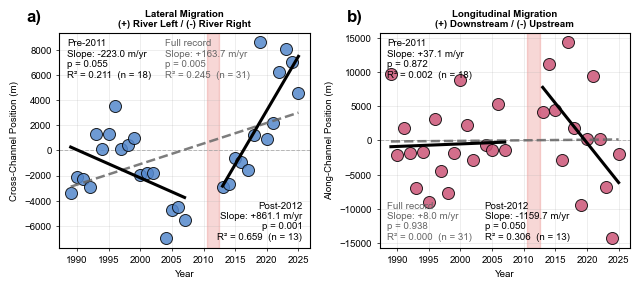

In [12]:
import matplotlib.pyplot as plt

# ── Style ──────────────────────────────────────────────────────────────────
FONT_NAME = 'Arial'

LATERAL_MARKER    = '#5588cc'   # blue
STREAMWISE_MARKER = '#cc5577'   # red
PRE_LINE_COLOR    = '#000000'   # black, solid — pre-epoch
POST_LINE_COLOR   = '#000000'   # black, solid — post-epoch
FULL_LINE_COLOR   = '#666666'   # gray, dashed — full record
ZERO_LINE_COLOR   = '#999999'
GAP_SHADE_COLOR   = '#D7261E'   # light red — 2010-2012 data gap

MARKER_SIZE = 75    # larger data point markers

LATERAL_INFO    = trend_test_results['Lateral (cross)']
STREAMWISE_INFO = trend_test_results['Streamwise (along)']
LATERAL_PP      = prepost_results['Lateral (cross)']
STREAMWISE_PP   = prepost_results['Streamwise (along)']

def fmt_stat(label, info):
    return (f"{label}\n"
            f"Slope: {info['slope']:+.1f} m/yr\n"
            f"p = {info['p']:.3f}\n"
            f"R² = {info['r2']:.3f}  (n = {info['n']})")

def draw_panel(ax, info, prepost, marker_color, title, ylabel,
               full_box_position='upper-right',
               post_box_position='lower-right'):
    yrs = info['years']
    y   = info['y_raw']

    # Zero reference
    ax.axhline(0, color=ZERO_LINE_COLOR, lw=0.7, ls='--', alpha=0.7, zorder=1)

    # 2010-2012 data-gap shading (epoch boundary)
    ax.axvspan(PRE_END_YEAR + 0.5, POST_START_YEAR - 0.5,
               color=GAP_SHADE_COLOR, alpha=0.18, zorder=0)

    # Annual centroid markers
    ax.scatter(yrs, y, s=MARKER_SIZE, color=marker_color, edgecolor='black',
               linewidth=0.7, alpha=0.85, zorder=3)

    # Full-record trendline (dashed, gray, drawn first so solid lines sit on top)
    full = prepost['full']
    if not np.isnan(full['slope']):
        x_full = np.array([yrs.min(), yrs.max()])
        y_full = full['intercept'] + full['slope'] * x_full
        ax.plot(x_full, y_full, color=FULL_LINE_COLOR, lw=1.8,
                ls='--', alpha=0.85, zorder=4)

    # Pre-epoch trendline
    pre = prepost['pre']
    if not np.isnan(pre['slope']):
        pre_yrs = yrs[prepost['pre_mask']]
        x_pre = np.array([pre_yrs.min(), pre_yrs.max()])
        y_pre = pre['intercept'] + pre['slope'] * x_pre
        ax.plot(x_pre, y_pre, color=PRE_LINE_COLOR, lw=2.2, zorder=5)

    # Post-epoch trendline
    post = prepost['post']
    if not np.isnan(post['slope']):
        post_yrs = yrs[prepost['post_mask']]
        x_post = np.array([post_yrs.min(), post_yrs.max()])
        y_post = post['intercept'] + post['slope'] * x_post
        ax.plot(x_post, y_post, color=POST_LINE_COLOR, lw=2.2, zorder=5)

    # Three stat labels — bare text, no boxes, no background
    pre_text  = fmt_stat("Pre-2011",    pre)
    post_text = fmt_stat("Post-2012",   post)
    full_text = fmt_stat("Full record", full)

    # Pre-2011 label: always upper-left
    ax.text(0.03, 0.97, pre_text, transform=ax.transAxes,
            fontsize=7, fontname=FONT_NAME, va='top', ha='left',
            zorder=6)

    # Post-2012 label: position varies by panel
    if post_box_position == 'lower-right':
        pb_x, pb_y, pb_va, pb_ha = 0.97, 0.03, 'bottom', 'right'
    elif post_box_position == 'lower-left-next-to-full':
        # Just to the right of the lower-left full-record label
        pb_x, pb_y, pb_va, pb_ha = 0.42, 0.03, 'bottom', 'left'
    else:
        pb_x, pb_y, pb_va, pb_ha = 0.97, 0.03, 'bottom', 'right'

    ax.text(pb_x, pb_y, post_text, transform=ax.transAxes,
            fontsize=7, fontname=FONT_NAME, va=pb_va, ha=pb_ha,
            zorder=6)

    # Full-record label: position varies by panel to avoid overlapping data
    if full_box_position == 'upper-right':
        fb_x, fb_y, fb_va, fb_ha = 0.97, 0.97, 'top',    'right'
    elif full_box_position == 'upper-left-next-to-pre':
        fb_x, fb_y, fb_va, fb_ha = 0.42, 0.97, 'top',    'left'
    elif full_box_position == 'lower-left':
        fb_x, fb_y, fb_va, fb_ha = 0.03, 0.03, 'bottom', 'left'
    else:
        fb_x, fb_y, fb_va, fb_ha = 0.97, 0.97, 'top',    'right'

    ax.text(fb_x, fb_y, full_text, transform=ax.transAxes,
            fontsize=7, fontname=FONT_NAME, va=fb_va, ha=fb_ha,
            color=FULL_LINE_COLOR, zorder=6)

    # Cosmetics
    ax.set_title(title, fontname=FONT_NAME, fontsize=7, fontweight='bold', pad=4)
    ax.set_xlabel('Year', fontname=FONT_NAME, fontsize=7)
    ax.set_ylabel(ylabel, fontname=FONT_NAME, fontsize=7)
    ax.tick_params(axis='both', labelsize=7, length=2, width=0.5)
    ax.grid(True, alpha=0.3, lw=0.5)
    for s in ax.spines.values():
        s.set_linewidth(0.8)

plt.rcParams['font.family'] = FONT_NAME
fig, axes = plt.subplots(1, 2, figsize=(6.5, 3.0))

# Panel a — Lateral (full-record box placed next to the pre-2011 box)
draw_panel(
    ax=axes[0],
    info=LATERAL_INFO,
    prepost=LATERAL_PP,
    marker_color=LATERAL_MARKER,
    title='Lateral Migration\n(+) River Left / (-) River Right',
    ylabel='Cross-Channel Position (m)',
    full_box_position='upper-left-next-to-pre',
)
axes[0].text(-0.13, 1.05, 'a)', transform=axes[0].transAxes,
             fontsize=12, fontname=FONT_NAME, fontweight='bold')

# Panel b — Streamwise (full-record box placed in lower-left)
draw_panel(
    ax=axes[1],
    info=STREAMWISE_INFO,
    prepost=STREAMWISE_PP,
    marker_color=STREAMWISE_MARKER,
    title='Longitudinal Migration\n(+) Downstream / (-) Upstream',
    ylabel='Along-Channel Position (m)',
    full_box_position='lower-left',
    post_box_position='lower-left-next-to-full',
)
axes[1].text(-0.13, 1.05, 'b)', transform=axes[1].transAxes,
             fontsize=12, fontname=FONT_NAME, fontweight='bold')

plt.tight_layout()

# Save
for ext in ('png', 'pdf', 'jpg'):
    out = f'{FIG_OUT_STEM}.{ext}'
    if ext == 'jpg':
        fig.savefig(out, dpi=1000, bbox_inches='tight', facecolor='white')
    else:
        fig.savefig(out, dpi=1000, bbox_inches='tight', transparent=True)
    print(f'  ✓ Saved {out}')

plt.show()

## §6 · Summary

This notebook produced:

| Step | Output |
|---|---|
| §1 | `Centroid_Monthly_<CONFIG_TAG>.csv` (plus `centroid_weighted_all.csv` alias when running the canonical weighted four-class variant) |
| §2 | `Centroid_Annual_<CONFIG_TAG>.csv` |
| §3 | Trend & change-point test summary table (printed) |
| §4 | Pre/post-break OLS slope summary (printed) |
| §5 | `Figure5_<CONFIG_TAG>.{png,pdf,jpg}` |

### Method references

- Mann (1945); Kendall (1975) — Mann–Kendall trend test
- Sen (1968) — Sen's slope
- Sneyers (1990) — sequential Mann–Kendall
- Pettitt (1979) — change-point test
- Yue, Pilon, Phinney & Cavadias (2002) — trend-free pre-whitening